In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

Multiprocessing: Below initialize julia on 7 cores

In [8]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([ 9, 10, 11, 12, 13, 14, 15], dtype=int64)

In [9]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("multiprocessing.jl")

<PyCall.jlwrap run_distributed_computation>

In [10]:
EEC=np.array([0.272,0.299,0.329,0.365,0.410,0.457,0.521,0.595,0.682,0.783,0.906,1.049,1.19,1.31,1.34,1.12,0.46])
χ_list=np.pi*np.array([150.3,152.1,153.9,155.7,157.5,159.3,161.1,162.9,164.7,166.5,168.3,170.1,171.9,173.7,175.5,177.3,179.1])/180

xlist = np.pi/180*np.linspace(150,179.9,num=20)
length=len(xlist)

v_1 = Main.run_distributed_computation(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=1, cores=7)
v_2 = Main.run_distributed_computation(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=2, cores=7)
v_3 = Main.run_distributed_computation(Q=91.2, χ_list=xlist, μ_ini=91.1876, αs_ini=0.118, nf=5, μ=91.1876, order=3, cores=7)

Close previous julias

In [11]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000016ff5f60f90>

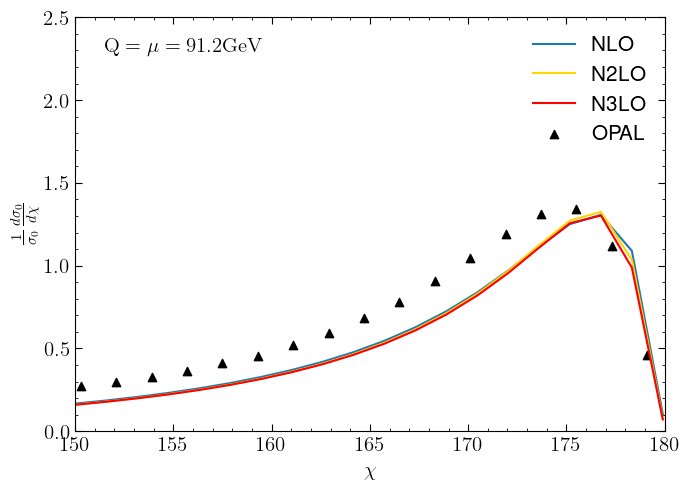

In [12]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, v_1, label="NLO")
ax1.plot(xlist*180/np.pi, v_2, label="N2LO",color="gold")
ax1.plot(xlist*180/np.pi, v_3, label="N3LO",color="red")
ax1.scatter(χ_list*180/np.pi, EEC, label="OPAL",marker="^",color="black")
ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.05, 0.95,  r"\rm $ \mathrm{Q}=\mu=91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,2.5)
plt.xlim(150,180)

plt.tight_layout()  
plt.show()